In [25]:

from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

In [52]:
import math

class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self._prev = set(_children)
        self._op = _op
        self.label = label
        self.grad = 0.0
        self._backward = lambda: None

    def __repr__(self):
        return f"Value(data={self.data})"

    
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad

        out._backward = _backward
        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad

        out._backward = _backward
        return out
    
    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data ** other, (self, ), f'**{other}')
        def _backward():
            self.grad += other * (self.data ** (other - 1)) * out.grad

        out._backward = _backward
        return out

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')

        def _backward():
            self.grad += (1 - t**2) * out.grad

        out._backward = _backward
        return out
    
    def __neg__(self):
        return self * -1
    
    def __sub__(self, other):
        return self + (-other)
    
    def __truediv__(self, other):
        return self * other**-1
    
    def __rsub__(self, other):
        return (-self) + other

    def __radd__(self, other):
        return self + other
    
    def __rmul__(self, other):
        return self * other

    def backward(self):
        visited = set()
        topo = []

        def topo_sort(v):
            if v not in visited:
                visited.add(v)
            for child in v._prev:
                topo_sort(child)
            topo.append(v)
        
        topo_sort(self)
        self.grad = 1.0

        for node in reversed(topo):
            node._backward()
            


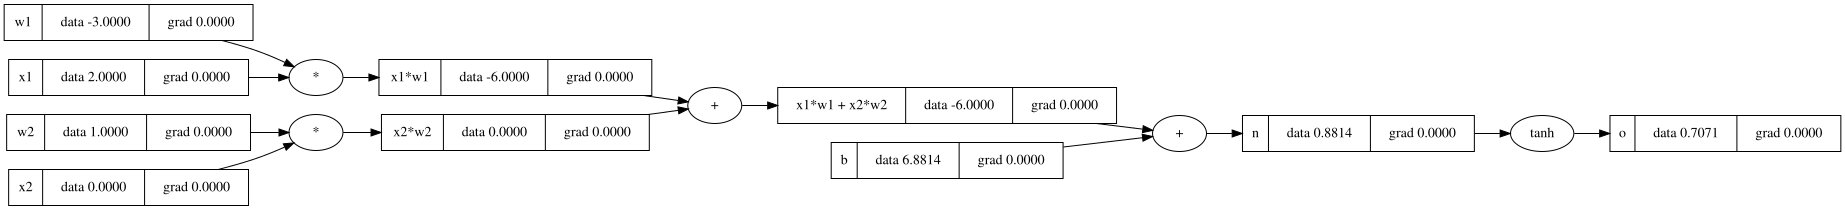

In [53]:

# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

draw_dot(o)


In [54]:
import random

class Neuron:
    def __init__(self, nin):
        self.weights = [Value(random.uniform(-1, 1)) for _ in range(nin)]
        self.bias = Value(random.uniform(-1, 1))

    def __call__(self, x):
        zi = sum((wi * xi for wi, xi in zip(self.weights, x)), self.bias)
        return zi.tanh()
    
    def parameters(self):
        return self.weights + [self.bias]
    


In [55]:
class Layer:
    def __init__(self, nin, nout):
        self.neurons = [ Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs
    
    def parameters(self):
        return [param for neuron in self.neurons for param in neuron.parameters()]

In [56]:
class MLP:
    def __init__(self, nin, nouts):
        al = [nin] + nouts
        self.layers = [Layer(al[i], al[i+1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x
    
    def parameters(self):
        return [param for layer in self.layers for param in layer.parameters()]


In [57]:
x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])
n(x)

Value(data=-0.4930867485416781)

In [58]:
xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets

In [59]:
epochs = 100
learning_rate = 0.1

for epoch in range(epochs):
    y_pred = [n(x) for x in xs]
    loss = sum((y - yout)**2 for y, yout in zip(ys, y_pred))

    for p in n.parameters():
        p.grad = 0.0
    loss.backward()

    for p in n.parameters():
        p.data -= learning_rate * p.grad

    print(f"epoch: {epoch} | loss: {loss.data}")

epoch: 0 | loss: 5.379167303053661
epoch: 1 | loss: 5.201537366947297
epoch: 2 | loss: 5.146939442265918
epoch: 3 | loss: 5.037490447994781
epoch: 4 | loss: 4.927628148360556
epoch: 5 | loss: 5.003987646978801
epoch: 6 | loss: 4.8659647305976
epoch: 7 | loss: 4.942073187546797
epoch: 8 | loss: 4.841508469967288
epoch: 9 | loss: 4.890813114760645
epoch: 10 | loss: 4.810147064210603
epoch: 11 | loss: 4.84277078834266
epoch: 12 | loss: 4.769077261159152
epoch: 13 | loss: 4.7888208567619595
epoch: 14 | loss: 4.717173416070583
epoch: 15 | loss: 4.723457799144807
epoch: 16 | loss: 4.654095705223868
epoch: 17 | loss: 4.6443581527728
epoch: 18 | loss: 4.578083241313333
epoch: 19 | loss: 4.550908946483523
epoch: 20 | loss: 4.491652917571557
epoch: 21 | loss: 4.449094779508381
epoch: 22 | loss: 4.400052899014053
epoch: 23 | loss: 4.349564814519197
epoch: 24 | loss: 4.311895489982238
epoch: 25 | loss: 4.2629780603209735
epoch: 26 | loss: 4.2352135236575394
epoch: 27 | loss: 4.194196147498534
epoc